# **Stereo Vision & Disparity Maps**

## **Objectives:**
1. Understand disparity — how much a point shifts between a left and right view — and why it encodes depth
2. Compute a disparity map with `cv2.StereoBM` and `cv2.StereoSGBM`
3. Check the result against real, measured ground truth

> **Assets.** `assets/images/aloeL.jpg` / `aloeR.jpg` / `aloeGT.png` are OpenCV's own official stereo sample ([opencv/opencv, Apache 2.0](https://github.com/opencv/opencv/tree/4.x/samples/data)) — a real rectified stereo pair (a potted aloe plant) with a genuine, separately-measured ground-truth disparity map, in the tradition of the Middlebury Stereo dataset. Having real ground truth is what makes the comparison at the end of this notebook honest instead of "the disparity map looks plausible."

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if image.ndim == 3 else image, cmap=None if image.ndim == 3 else 'gray')
    plt.title(title)
    plt.show()

## **Disparity, intuitively**

Hold a finger up close and alternate closing each eye — it appears to jump sideways by a lot. Do the same with something across the room and it barely moves. That sideways shift is **disparity**, and stereo vision runs that observation backwards: measure the shift, recover the distance.

For a *rectified* stereo pair (both cameras' image planes aligned so rows line up — already true for `aloeL`/`aloeR`), a point at real-world depth $Z$ shows up shifted horizontally by:

$$d = \frac{f \cdot B}{Z}$$

where $f$ is focal length (pixels) and $B$ is the **baseline**, the distance between the two camera centers. The relationship is *inverse*: nearby objects have large disparity, far objects have small disparity — and it flattens out fast, which is exactly why stereo depth gets unreliable at long range with a small baseline (the same reason your two eyes, a few centimeters apart, are only good for near-field depth judgment).

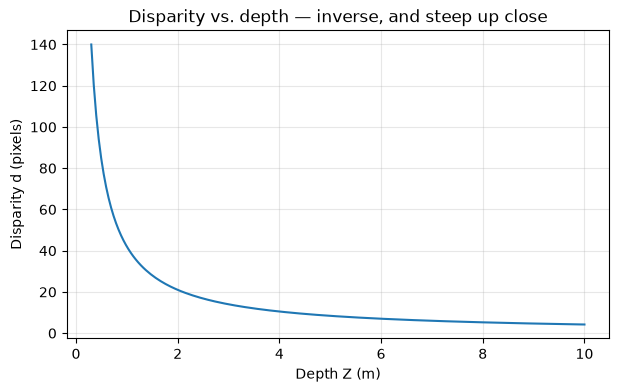

In [2]:
Z = np.linspace(0.3, 10, 200)   # meters
f, B = 700, 0.06                # example: 700px focal length, 6cm baseline
d = f * B / Z

plt.figure(figsize=(7, 4))
plt.plot(Z, d)
plt.xlabel('Depth Z (m)')
plt.ylabel('Disparity d (pixels)')
plt.title('Disparity vs. depth — inverse, and steep up close')
plt.grid(alpha=0.3)
plt.show()

## **Computing disparity: BM vs. SGBM**

Both algorithms slide a small window along each row of the right image to find the best match for each pixel in the left image (this is the same matching-cost idea as `cv2.matchTemplate` from notebook 14, just repeated along one scanline per pixel instead of once over a whole image):

- **`StereoBM`** (Block Matching) — fast, purely local: each pixel's best match is chosen independently, which leaves visible noise in low-texture regions where many nearby windows match almost equally well.
- **`StereoSGBM`** (Semi-Global Block Matching) — adds a smoothness penalty (`P1`, `P2`) that discourages disparity from jumping around between neighboring pixels unless the image really supports it, aggregated along several directions across the image. Slower, visibly cleaner.

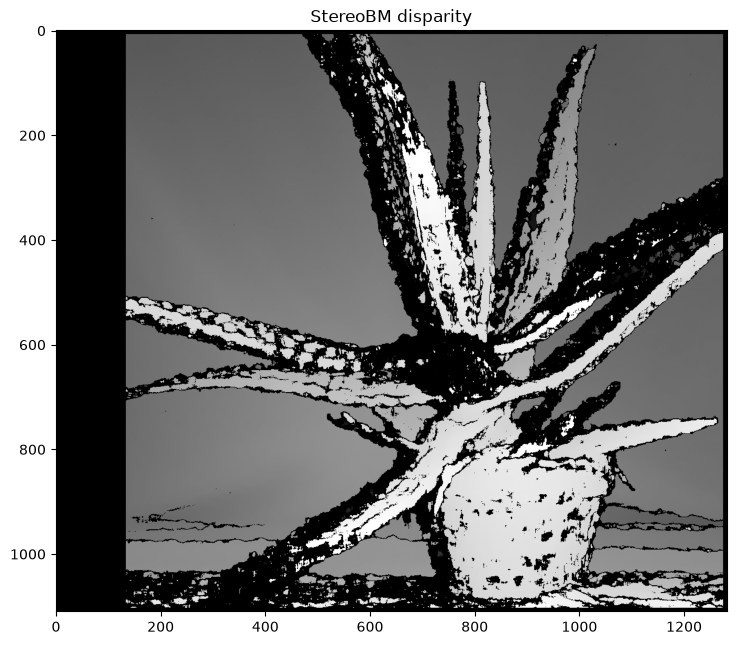

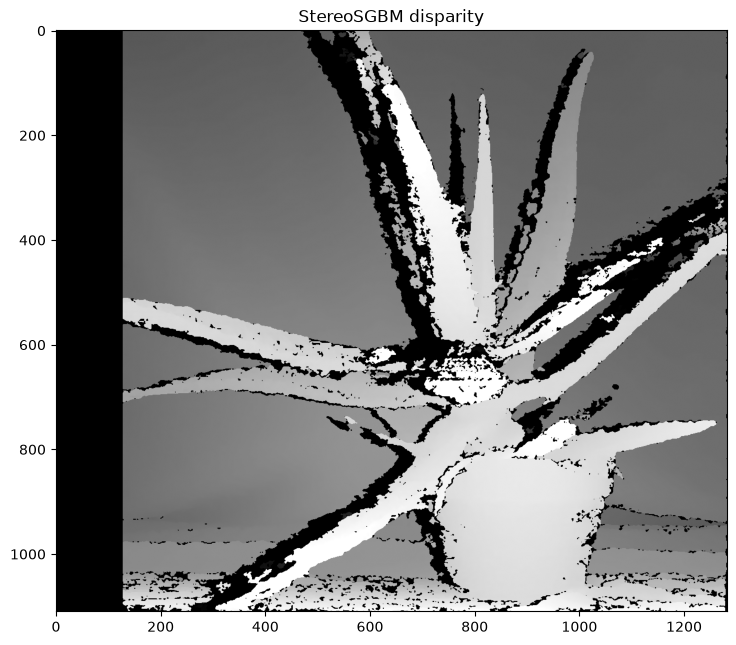

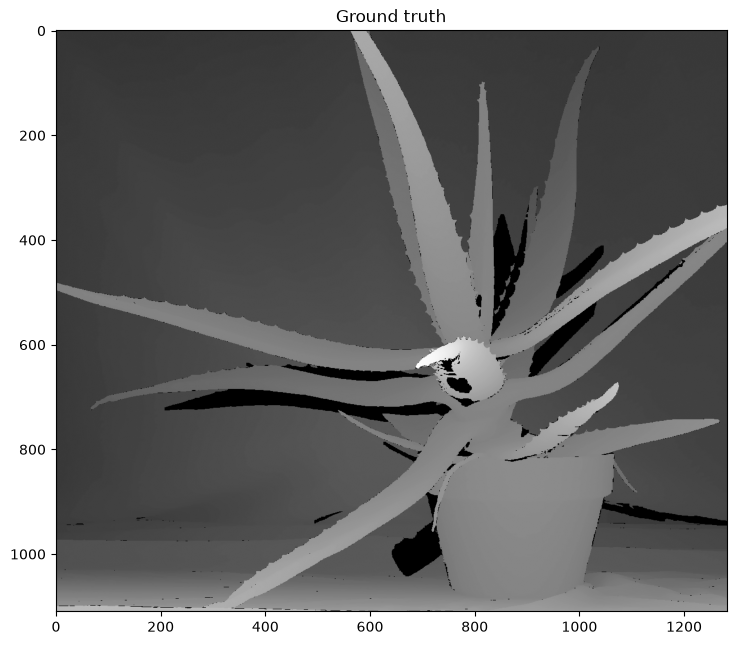

In [3]:
aloe_l = cv2.imread('assets/images/aloeL.jpg', cv2.IMREAD_GRAYSCALE)
aloe_r = cv2.imread('assets/images/aloeR.jpg', cv2.IMREAD_GRAYSCALE)
aloe_gt = cv2.imread('assets/images/aloeGT.png', cv2.IMREAD_GRAYSCALE)

num_disp = 16 * 8  # must be divisible by 16

bm = cv2.StereoBM_create(numDisparities=num_disp, blockSize=15)
disp_bm = bm.compute(aloe_l, aloe_r).astype(np.float32) / 16.0

sgbm = cv2.StereoSGBM_create(
    minDisparity=0, numDisparities=num_disp, blockSize=5,
    P1=8 * 3 * 5 ** 2, P2=32 * 3 * 5 ** 2,
    disp12MaxDiff=1, uniquenessRatio=10,
    speckleWindowSize=100, speckleRange=32,
)
disp_sgbm = sgbm.compute(aloe_l, aloe_r).astype(np.float32) / 16.0

def normalize_disp(d):
    d = np.clip(d, 0, None)
    return cv2.normalize(d, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

imshow('StereoBM disparity', normalize_disp(disp_bm))
imshow('StereoSGBM disparity', normalize_disp(disp_sgbm))
imshow('Ground truth', aloe_gt)

## **Checking against ground truth**

`aloeGT.png` isn't estimated from these two photos at all — it comes from a separate, independent measurement, which is what makes this a genuine accuracy check rather than a self-consistency check. Comparing correlation against the *background* (a flat, distant wall — easy for any stereo algorithm) versus the *foreground leaves* (thin, high-frequency structure — hard for any window-matching algorithm) is more informative than one single number over the whole image.

In [4]:
def masked_corr(disp, gt, mask):
    d, g = disp[mask], gt[mask].astype(np.float32)
    valid = d > 0
    if valid.sum() < 2 or g[valid].std() == 0:
        return None  # undefined — see the note on the background region below
    return np.corrcoef(d[valid], g[valid])[0, 1]

# a rough foreground/background split straight from the ground truth itself
background = aloe_gt < 40
foreground = aloe_gt >= 40

for name, disp in [('StereoBM', disp_bm), ('StereoSGBM', disp_sgbm)]:
    bg_corr = masked_corr(disp, aloe_gt, background)
    fg_corr = masked_corr(disp, aloe_gt, foreground)
    bg_str = f'{bg_corr:.2f}' if bg_corr is not None else 'undefined (see below)'
    print(f'{name}: background corr={bg_str}, foreground (leaves) corr={fg_corr:.2f}')

print()
print('The background correlation is undefined, not a bug: aloeGT.png labels the '
      'entire wall as a flat 0 rather than a measured depth — a real admission that '
      'depth on a flat, textureless wall cannot be reliably measured by *any* stereo '
      'method, including whatever produced this ground truth. Both algorithms track '
      'the leaves (real texture, real disparity) closely; neither can be graded on '
      'the wall because nothing here claims to know its true depth either.')

StereoBM: background corr=undefined (see below), foreground (leaves) corr=0.96
StereoSGBM: background corr=undefined (see below), foreground (leaves) corr=0.93

The background correlation is undefined, not a bug: aloeGT.png labels the entire wall as a flat 0 rather than a measured depth — a real admission that depth on a flat, textureless wall cannot be reliably measured by *any* stereo method, including whatever produced this ground truth. Both algorithms track the leaves (real texture, real disparity) closely; neither can be graded on the wall because nothing here claims to know its true depth either.


### A couple of directions to take this

- Use notebook 31's chessboard set — `calib/left*.jpg` **and** the matching `calib/right*.jpg` — with `cv2.stereoCalibrate` and `cv2.stereoRectify` to get real rectification maps for a genuinely uncalibrated pair, instead of relying on `aloeL`/`aloeR` already being rectified for you.
- Sweep `StereoSGBM`'s `uniquenessRatio` and `speckleWindowSize` and watch the noisy speckle in flat regions (like the background wall) disappear — at the cost of losing some real detail in the thin leaves.
- Convert disparity to actual depth in meters with `Z = f * B / d`, using a plausible `f`/`B` for how `aloeL.jpg`/`aloeR.jpg` were likely captured, and turn the result into a rough 3D point cloud with `cv2.reprojectImageTo3D`.